# DAY - 24
# DATE - 13.06.2026
# InSAR Basics + SAR Change Detection

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. GENERATING SYNTHETIC SAR DATA (Since you don't have the files)
# -------------------------------------------------------------

In [3]:
np.random.seed(42)
image_size = (256, 256)

# Base land backscatter (mean brightness = 0.5) + adding radar speckle noise
speckle_noise_before = np.random.exponential(scale = 0.2, size = image_size)
img_before = 0.5 + speckle_noise_before

# Copying before image to after image
img_after = img_before.copy()

# Simulating a flood: We create a square region in the center where water sits.
# Water surface is smooth, so backscatter drops heavily (mean brightness drops to 0.05)
flood_zone_y, flood_zone_x = slice(80, 180), slice(80, 180)
speckle_noise_after = np.random.exponential(scale=0.02, size=(100, 100))
img_after[flood_zone_y, flood_zone_x] = 0.05 + speckle_noise_after

# -------------------------------------------------------------
# 2. SAR LOG RATIO PROCESSING
# -------------------------------------------------------------


In [4]:
epsilon = 1e-6
img_before = np.clip(img_before, epsilon, None)
img_after = np.clip(img_after, epsilon, None)

# Calculate Log Ratio in decibels (dB)
log_ratio_db = 10 * np.log10(img_after / img_before)

# Apply threshold to extract flood (where signal dropped by more than -4 dB)
flood_threshold = -4.0
flood_mask = log_ratio_db < flood_threshold

# -------------------------------------------------------------
# 3. STATS & VISUALIZATION
# -------------------------------------------------------------

Total Pixels Analysed: 65536
Flooded Pixels Detected: 9999
Percentage of Area Flooded: 15.26%


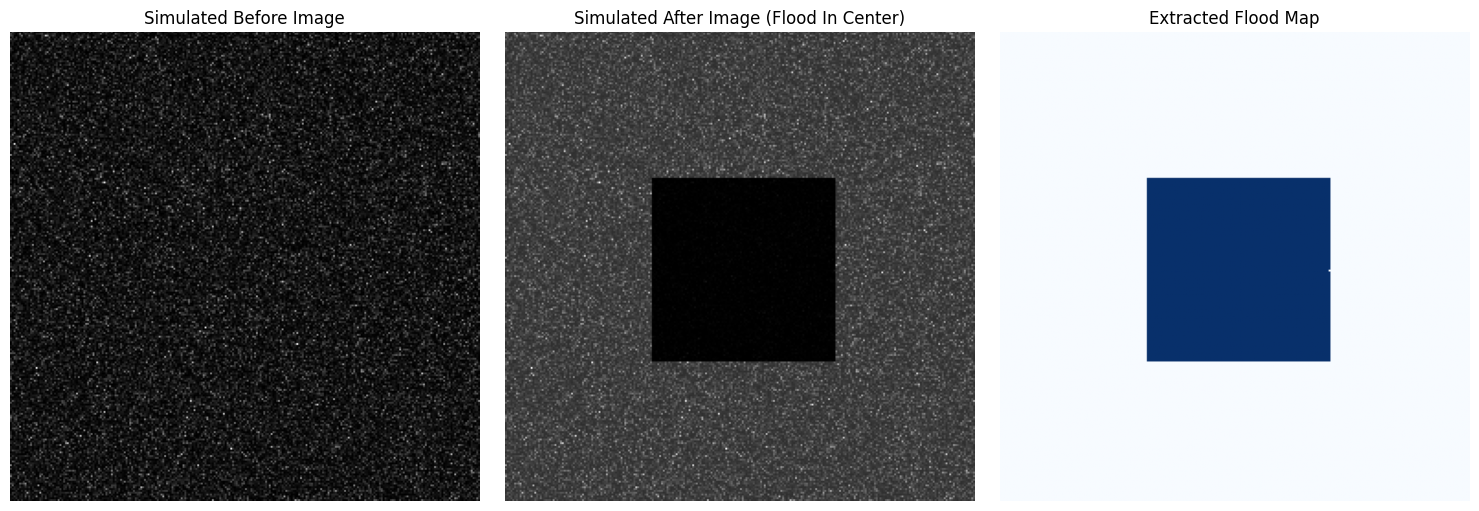

In [5]:
total_pixels = flood_mask.size
flooded_pixels = np.sum(flood_mask)
flood_percentage = (flooded_pixels / total_pixels) * 100

print(f"Total Pixels Analysed: {total_pixels}")
print(f"Flooded Pixels Detected: {flooded_pixels}")
print(f"Percentage of Area Flooded: {flood_percentage:.2f}%")

# plotting the results
plt.figure(figsize = (15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_before, cmap = 'gray')
plt.title('Simulated Before Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_after, cmap = 'gray')
plt.title('Simulated After Image (Flood In Center)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flood_mask, cmap = 'Blues')
plt.title('Extracted Flood Map')
plt.axis('off')

plt.tight_layout()
plt.show()